In [33]:
#Gemini-assisted here

T = Float64;
include("cheb.jl") 
using LinearAlgebra
using Plots
using Printf # For formatted printing
using LinearAlgebra
using ForwardDiff # Recommended to auto-calculate DDV


const N = 32; # Start with smaller N for testing. 128 is fine too.

# Precompute Grid and Matrices
const grid = chebgrid(0, 1, N);
const Dmat = chebmat(grid);
const D2mat = Dmat * Dmat;

# Constants
const phiM = 1.0;

# Potential Functions (Vectorized for performance)
# Note: Using dot syntax (.) for element-wise operations allows passing vectors directly
Vfun(x) = @. (x^6*(150 - 25*x^2) + phiM^2*(x^6*(-100 + x^2*(-180 + 20*x^2)) + phiM^2*(-900 + x^2*(-450 + x^2*(-100 + x^2*(-60 + x^2*(40 + x^2*(54 - 4*x^2))))))))/(300*phiM^4);
DV(x)   = @. (x^5*(225 - 50*x^2) + phiM^2*(x^5*(-150 + x^2*(-360 + 50*x^2)) + phiM^2*x*(-225 + x^2*(-100 + x^2*(-90 + x^2*(80 + x^2*(135 - 12*x^2)))))))/(75*phiM^4);
DDV(x) = ForwardDiff.derivative(DV, x)

function ComputeStaticEquations(varvec, Hh)
    # 1. Unpack variables
    # Views are faster (no copying), but slices are safer for beginners. 
    # Let's use slices for clarity.
    S = varvec[1:N];     
    A = varvec[N+1:2*N]; 
    H = varvec[2*N+1:3*N]; 

    # 2. Compute Derivatives via Matrix Multiplication
    Su = Dmat * S;  Suu = D2mat * S;
    Au = Dmat * A;  Auu = D2mat * A;
    Hu = Dmat * H;  Huu = D2mat * H;

    # 3. Compute Residuals (Vectorized)
    # Initialize with the bulk equations

    # Eq 1
    Res1 = @. 2 * Hu^2 * S + 3 * Suu
    
    # Eq 2
    Res2 = @. 6*A*(4*S - 3*Su*grid) + 3*grid*(-5*Au*S + Auu*S*grid + 3*Au*Su*grid) + 8*S*Vfun(H)
    
    # Eq 3
    function regularized_term(H_val, Hu_val, u_val)
    # If u is safely away from 0, compute normally
        if abs(u_val) > 1e-6
            return DV(H_val) / u_val
        else
            # Limit u -> 0
            return -3.0 * Hu_val
        end
    end
    DV_over_u = regularized_term.(H, Hu, grid)

    Res3 = @. 3*A*Hu*Su*grid + S*(-3*A*Hu + Au*Hu*grid + A*Huu*grid - DV_over_u)

    # 4. Apply Boundary Conditions
    # Index 1 corresponds to u = 0 (or boundary 1)
    # Index N corresponds to u = 1 (or boundary 2)
    
    # Boundary at i = 1
    Res1[1] = S[1] - 1.0
    Res2[1] = A[1] - 1.0
    Res3[1] = H[1]
    
    # Boundary at i = N
    Res2[N] = A[N]     
    Res3[N] = H[N] - Hh  

    return vcat(Res1, Res2, Res3)
end

function ComputeJacobian(varvec, Hh)
    dof = 3 * N
    Jac = zeros(dof, dof)
    eps = 1e-7
    locvec = copy(varvec)
    
    # Pre-compute central value
    f0 = ComputeStaticEquations(locvec, Hh)
    
    for i in 1:dof
        orig = locvec[i]
        
        locvec[i] = orig + eps
        fp = ComputeStaticEquations(locvec, Hh)
        
        # Simple forward difference is often enough and 2x faster
        Jac[:, i] = (fp - f0) / eps
        
        locvec[i] = orig # Restore
    end
    return Jac
end

function newton_solve(initial_guess,Hh)
    state = copy(initial_guess)
    max_iter = 20
    tol = 1e-5
    
    for iter in 1:max_iter
        # Calculate Residual and Jacobian
        F = ComputeStaticEquations(state, Hh)
        err = norm(F, Inf)
        print("HERE, ",iter," ",err,"\n");
        if err < tol
            @printf("Converged for Hh=%.4f in %d iters. Error: %.2e\n", Hh, iter, err)
            return state, true
        end

        J = ComputeJacobian(state, Hh)
        
        # Calculate step
        delta = J \ F
        
        # Damping / Line Search (Simple)
        # Prevents the solver from exploding if the full step is too bad
        step_size = 1.0
        new_state = state - step_size * delta
        
        # Simple backtracking: if error grows significantly, reduce step
        # (This is a basic implementation, can be made more robust)
        while norm(ComputeStaticEquations(new_state, Hh), Inf) > 10*err && step_size > 0.1
            step_size *= 0.5
            new_state = state - step_size * delta
        end
        
        state = new_state
    end
    
    @printf("WARNING: Failed to converge for Hh=%.4f. Final Error: %.2e\n", Hh, err)
    return state, false
end

newton_solve (generic function with 1 method)

In [34]:
ComputeJacobian(guessvec,.1)

96×96 Matrix{Float64}:
      1.0              0.0             0.0         …     0.0         0.0
      3.42188e5       -4.89732e5       1.7804e5          4.02063    -2.00514
 -21552.6          83088.1            -1.02072e5        -4.05187     2.02068
   4312.65        -11330.3         32195.6               4.10465    -2.04694
  -1389.6           3230.72        -5370.67             -4.18011     2.08446
    582.763        -1282.61         1745.75        …     4.27987    -2.13408
   -289.342          618.4          -762.034            -4.40618     2.19688
    161.716         -339.616         395.203             4.56197    -2.27433
    -98.7421         205.027        -230.106            -4.75106     2.36831
     64.6134        -133.126         145.808             4.9783     -2.48123
    -44.7289          91.6473        -98.6597      …    -5.24992     2.61615
     32.4613         -66.239          70.4078            5.57389    -2.77702
    -24.5377          49.9142        -52.5476           -

In [35]:
det(ComputeJacobian(guessvec,.1))

-1.8417122048073342e255

In [37]:
newton_solve(guessvec,.1)

HERE, 1 26.308063962675487
HERE, 2 559406.6444693633
HERE, 3 26432.786415267023
HERE, 4 149963.81531524242
HERE, 5 2.5544482373816066e14
HERE, 6 2.3100594943706795e15
HERE, 7 5.997646230147984e9
HERE, 8 4.514151486803804e9
HERE, 9 4.965696158077298e27
HERE, 10 6.329915171194877e18
HERE, 11 3.9937963755885234e13
HERE, 12 6.713047492427169e9
HERE, 13 2.521591023758763e9
HERE, 14 3.7788715904072165e9
HERE, 15 3.4788524386196623e9
HERE, 16 2.9706695492661104e9
HERE, 17 1.3956735929621187e17
HERE, 18 1.3211304558536933e17


LoadError: SingularException(49)

In [30]:
Sguess = ones(N)
Aguess = [1 - u/grid[end] for u in grid]
Hguess = grid;

guessvec = vcat(Sguess, Aguess, Hguess);

# newton_solve(.1,guessvec)

In [ ]:
function main_continuation()
    Sguess = ones(N)
    Aguess = [1 - u/grid[end] for u in grid]
    Hguess = zeros(N)
    
    current_state = vcat(Sguess, Aguess, Hguess)
    
    # Target values for Hh
    H_targets = 0.1:0.1:2.0 # Adjust range as needed
    
    results = []
    
    for H_val in H_targets
        # Use the solution from the PREVIOUS H_val as the guess for the CURRENT H_val
        current_state, success = newton_solve(H_val, current_state)
        
        if !success
            println("Stopping continuation due to convergence failure.")
            break
        end
        
        # Store result (e.g., value at origin)
        push!(results, (H_val, current_state[1])) # Saving S(0)
    end
    
    return results
end

In [16]:
tmp=solveEq(.45);

No convergence! Hh = 0.45


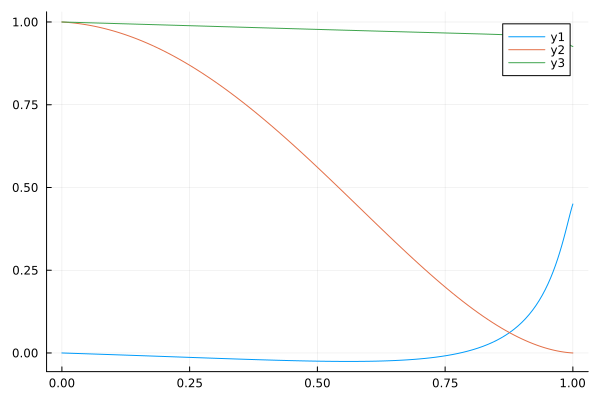

In [17]:
plot(grid, tmp[2*N+1:3*N])
plot!(grid, tmp[N+1:2*N])
plot!(grid, tmp[1:N])

In [4]:
function solveEq(Hh)
    Sguess = ones(N); Aguess = [1-u/grid[end] for u in grid]; Hguess = [u*Hh/grid[end] for u in grid];
    guessvec = vcat(Sguess,Aguess,Hguess);
    state_vec = copy(guessvec)

    for iter in 1:10
        eq_vec = ComputeStaticEquations(state_vec, Hh);
        Jac_mat = ComputeJacobian(state_vec, Hh);

        change_vec = Jac_mat \ eq_vec;
        state_vec -= change_vec;

        err = norm(ComputeStaticEquations(state_vec,Hh ));
        # print(err,"\n");

        if err<1.e-4
            break
        end
        
        if iter==10 
            print("No convergence! Hh = ",Hh,"\n");
        end
    end
    return state_vec

end

solveEq (generic function with 1 method)

In [5]:
function ComputeEM(varvec)
    Svec = varvec[1:N]; Avec = varvec[N+1:2*N]; Hvec = varvec[2*N+1:3*N];

    ξ = (Dmat*Svec)[1];
    a4 = (D2mat*D2mat*Avec)[1]/24;
    p2 = (Dmat*D2mat*Hvec)[1]/6;

    en = 19/144 - 3*a4/4 - p2 + ξ^2;
    mom = 7/432 - a4/4 + p2/3 - ξ^2/3;

    return en,mom
end

ComputeEM (generic function with 1 method)

In [6]:
HhSweep = 0:.05:1.4;

In [7]:
entable = []; momtable = [];
for Hh in HhSweep
    vec = solveEq(Hh);
    en, mom = ComputeEM(vec);
    push!(entable, en); push!(momtable,mom);
end

No convergence! Hh = 0.45


LoadError: SingularException(130)